# Chapter 4: Linear Transformations of Subspaces

Source orientation: the PDF/page audit in this notebook records the printed and PDF page span used for chapter grounding; all prose, examples, visuals, and checks here are original course material.

This standalone notebook covers the Chapter 4 span verified from the PDF at printed pages 99-123, with printed page 125 beginning Chapter 5. The requested page range says 99-124; in this copy there is no printed Chapter 4 text on page 124.

Verified source headings for this notebook:

- 4.1 Linear transformations of vectors
- 4.2 Outermorphisms: linear transformations of blades
- 4.2.3 Determinants of linear transformations
- 4.3 Linear transformation of the metric products
- 4.3.2 The adjoint of a linear transformation
- 4.3.3 Linear transformation of the contraction
- 4.3.5 Transforming a dual representation
- 4.4 Inverses of outermorphisms
- 4.5 Matrix representations
- 4.9 Programming examples and exercises

The prose here is original. The goal is to rebuild the ideas as executable geometry: make a vector map, extend it to blades, check the invariants, and use the same rules for projection and normal-vector work.

## Working Setup

The notebook uses only `numpy`, `IPython`, and `ipywidgets` when widgets are available. Static SVG artifacts are written to `artifacts/chapter-04` so the important pictures survive outside the notebook output.

### Chapter map in plain language

Chapter 4 asks what it means to transform not only points or vectors, but entire subspaces.  If a linear map sends every vector to a new vector, then a line segment spanned by one vector, a parallelogram spanned by two vectors, and a volume spanned by three vectors should all move consistently.  The induced action on blades is called the outermorphism of the original map.  It is not an optional add-on: without it, a program can transform vertices while silently breaking areas, normals, orientations, and incidence tests.

The key idea is simple enough to state before the notation becomes dense.  Transform the ingredients first, then rebuild the oriented subspace from the transformed ingredients.  For a bivector, apply the matrix to each spanning vector and wedge the results.  For a trivector, apply the matrix to all three spanning vectors and wedge those.  This rule preserves linearity and antisymmetry because it inherits both properties from the outer product.  It also explains why singular maps are visible in the algebra: if a transformation crushes a plane into a line, the transformed bivector loses area and can become zero.

The chapter also introduces the adjoint because measurements must move carefully.  A vector transformed by `M` lives in the transformed space, but a covector, normal, or dual object often has to transform by the inverse transpose or adjoint relation so that scalar products keep their meaning.  Graphics programmers see this as the normal-matrix rule; geometric algebra treats it as one instance of a broader compatibility condition between maps, products, and duals.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
from IPython.display import HTML, SVG, display

try:
    import ipywidgets as widgets
except Exception:
    widgets = None

BOOK_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils" / "chapter04_linear_transformations.py").exists():
        BOOK_ROOT = candidate
        break

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.chapter04_linear_transformations import (
    adjoint_matrix,
    apply_matrix,
    bivector_to_normal,
    checks_as_dicts,
    demo_matrix,
    directional_line_projection,
    exterior_power_matrix,
    inverse_adjoint_matrix,
    left_contract_vector_bivector,
    normal_transform,
    project_vector_to_subspace,
    rotation2,
    run_invariant_checks,
    scalar_product_blades,
    shear2,
    svg_linear_map,
    svg_normal_transform_lab,
    svg_projection_lab,
    transformed_metric,
    unit,
    wedge_vectors,
)

np.set_printoptions(precision=4, suppress=True)
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "chapter-04"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"project root: {BOOK_ROOT}")
print(f"artifact root: {ARTIFACT_ROOT}")

project root: Geometric-Algebra-for-Computer-Science
artifact root: Geometric-Algebra-for-Computer-Science/artifacts/chapter-04


In [2]:
def write_text_artifact(filename, text):
    path = ARTIFACT_ROOT / filename
    path.write_text(text, encoding="utf-8")
    return path


def write_json_artifact(filename, payload):
    path = ARTIFACT_ROOT / filename
    path.write_text(json.dumps(payload, indent=2, sort_keys=True), encoding="utf-8")
    return path


def show_svg(svg_text, filename=None):
    if filename:
        path = write_text_artifact(filename, svg_text)
        print(f"wrote {path}")
    display(SVG(svg_text))


def residual(name, value, tol=1e-9):
    value = float(value)
    print(f"{name}: {value:.3e}")
    assert abs(value) <= tol, f"{name} residual {value} exceeds {tol}"

## 1. Vector Linear Maps

A linear map is completely determined by where it sends a basis. With column-vector matrices, the rule is `x -> M @ x`. The two checks that matter are additivity and scalar compatibility. In pictures, the origin stays fixed and a grid turns into another grid whose lines remain straight and evenly spaced.

The square below is not just a square. Read it as the unit 2-blade: its signed area is the grade-2 object that the vector map must transform consistently.

M2 =
[[ 1.2327 -0.0635]
 [ 0.5505  0.7602]]
linearity: 2.220e-16
wrote Geometric-Algebra-for-Computer-Science/artifacts/chapter-04/linear-map.svg


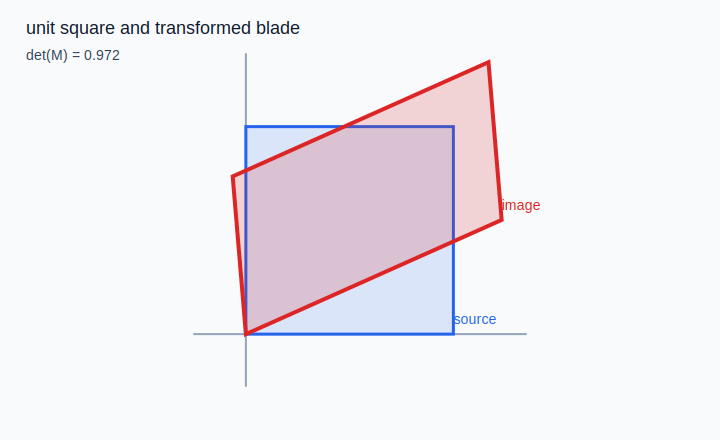

In [3]:
M2 = demo_matrix(angle=0.42, sx=1.35, sy=0.72, shear=0.35)
x = np.array([0.8, -0.25])
y = np.array([-0.35, 0.9])
alpha, beta = 1.7, -0.4
linearity = apply_matrix(M2, alpha * x + beta * y) - (alpha * apply_matrix(M2, x) + beta * apply_matrix(M2, y))

print("M2 =")
print(M2)
residual("linearity", np.linalg.norm(linearity))
show_svg(svg_linear_map(M2), "linear-map.svg")

In [4]:
if widgets is None:
    print("ipywidgets is not available in this runtime.")
else:
    angle = widgets.FloatSlider(value=0.42, min=-1.2, max=1.2, step=0.02, description="angle")
    sx = widgets.FloatSlider(value=1.35, min=0.35, max=2.2, step=0.05, description="sx")
    sy = widgets.FloatSlider(value=0.72, min=0.35, max=2.2, step=0.05, description="sy")
    shear = widgets.FloatSlider(value=0.35, min=-1.2, max=1.2, step=0.05, description="shear")

    @widgets.interact(angle=angle, sx=sx, sy=sy, shear=shear)
    def explore_vector_map(angle, sx, sy, shear):
        display(SVG(svg_linear_map(demo_matrix(angle=angle, sx=sx, sy=sy, shear=shear))))

interactive(children=(FloatSlider(value=0.42, description='angle', max=1.2, min=-1.2, step=0.02), FloatSlider(…

## 2. Outermorphisms

The vector map has a canonical extension to blades: transform each vector factor, then span the transformed factors. That extension is the outermorphism. It is not an optional extra rule; it is what lets a subspace keep its construction history.

For a 2-blade `a ^ b`, the coordinate vector of the transformed blade must match the grade-2 exterior-power matrix applied to the original blade coordinates.

### Why the outermorphism is the right extension

It is tempting to represent a blade by a coordinate array and ask a matrix to act on that array directly.  That can work after the correct matrix has been built, but it hides the reason the construction is correct.  A blade represents an oriented span.  The span is determined by its generators up to changes of basis inside the span, so a transformation of the blade must be independent of the particular generating vectors chosen.  Applying the vector map to each generator and then wedging the results has exactly that property.

This rule also preserves degeneracy information.  If two independent vectors are mapped into parallel vectors, their wedge vanishes.  That is not a numerical nuisance; it is the correct geometric answer that the transformed parallelogram has zero area.  If a map reverses orientation, the top-grade element changes sign.  If it scales one axis strongly and another weakly, the induced bivector scales by the product of those axis effects.  This is why determinants appear naturally instead of as a separate theorem: the determinant is the top-grade scale factor of the outermorphism.


In [5]:
M3 = np.array(
    [
        [1.15, -0.35, 0.20],
        [0.25, 0.92, -0.15],
        [0.05, 0.38, 1.08],
    ],
    dtype=float,
)
a = np.array([0.75, -0.20, 1.10])
b = np.array([-0.40, 0.95, 0.30])

blade = wedge_vectors(a, b)
image_by_spanning = wedge_vectors(apply_matrix(M3, a), apply_matrix(M3, b))
image_by_matrix = exterior_power_matrix(M3, 2) @ blade

print("bivector basis order: e12, e13, e23")
print("source blade:", blade)
print("image from transformed factors:", image_by_spanning)
print("image from grade-2 matrix:", image_by_matrix)
residual("outermorphism wedge check", np.linalg.norm(image_by_spanning - image_by_matrix))

bivector basis order: e12, e13, e23
source blade: [ 0.6325  0.665  -1.105 ]
image from transformed factors: [ 0.7219  1.6084 -0.9454]
image from grade-2 matrix: [ 0.7219  1.6084 -0.9454]
outermorphism wedge check: 3.140e-16


## 3. Determinants as Top-Grade Scaling

In an `n`-dimensional space, the top-grade blade is a signed volume element. A linear map can only send that one-dimensional top-grade space to a scaled copy of itself. That scale is the determinant.

This is a clean geometric definition: determinant means signed volume multiplier before it means a recipe with rows and columns.

In [6]:
c = np.array([1.00, 0.35, -0.60])
source_volume = wedge_vectors(a, b, c)[0]
image_volume = wedge_vectors(apply_matrix(M3, a), apply_matrix(M3, b), apply_matrix(M3, c))[0]
det_M3 = float(np.linalg.det(M3))

print(f"source trivector coordinate: {source_volume:.6f}")
print(f"image trivector coordinate:  {image_volume:.6f}")
print(f"det(M3) * source:          {det_M3 * source_volume:.6f}")
residual("determinant volume scaling", image_volume - det_M3 * source_volume)

source trivector coordinate: -1.717250
image trivector coordinate:  -2.258381
det(M3) * source:          -2.258381
determinant volume scaling: 0.000e+00


## 4. Adjoints and Transformed Scalar Products

A non-orthogonal map changes the metric seen in the source coordinates. The scalar product of transformed vectors is not usually `a dot b`; it is `a.T @ (M.T @ M) @ b` in Euclidean coordinates.

The adjoint is the companion map that moves a linear transformation from one slot of the scalar product to the other. In Euclidean coordinates, the adjoint matrix is the transpose. With a different metric, the metric matrix appears on both sides.

### The adjoint as a bookkeeping device for measurements

Linear transformations move objects, but measurements compare objects.  The adjoint is the map that lets those two activities commute.  In matrix language, it is the operation satisfying `<Mx, y> = <x, M^T y>` for the Euclidean inner product, with the metric-adjusted version used in other signatures.  In geometric language, the adjoint tells us how a measuring object must move so that the scalar answer remains the same.

This distinction matters in almost every application chapter.  A surface normal is not transformed like a tangent direction under a nonuniform scale, because the normal is defined by the planes it annihilates.  A camera plane, a dual line, or a constraint equation often belongs to the measurement side of the pairing.  The adjoint is therefore the bridge between direct representations, which transform by the outermorphism, and dual representations, which transform by the compatible inverse or adjoint action.

The code below checks the idea numerically rather than asking you to trust the notation.  It computes a scalar product before and after moving one side of the pairing through the adjoint relation.  The small residuals are the computational signature that the transformed formula is still measuring the same geometric fact.


In [7]:
adj = adjoint_matrix(M3)
pullback_metric = transformed_metric(M3)

left_scalar = np.dot(apply_matrix(M3, a), b)
right_scalar = np.dot(a, apply_matrix(adj, b))
transformed_left = np.dot(apply_matrix(M3, a), apply_matrix(M3, b))
transformed_right = a @ pullback_metric @ b

print("adjoint matrix =")
print(adj)
print("pullback metric M.T @ M =")
print(pullback_metric)
residual("adjoint identity", left_scalar - right_scalar)
residual("transformed scalar product", transformed_left - transformed_right)

adjoint matrix =
[[ 1.15  0.25  0.05]
 [-0.35  0.92  0.38]
 [ 0.2  -0.15  1.08]]
pullback metric M.T @ M =
[[ 1.3875 -0.1535  0.2465]
 [-0.1535  1.1133  0.2024]
 [ 0.2465  0.2024  1.2289]]
adjoint identity: 0.000e+00
transformed scalar product: 0.000e+00


In [8]:
# Same idea for a 2-blade: the squared area after transformation is the
# determinant of the Gram matrix measured with the pulled-back metric.
u = np.array([1.1, -0.2, 0.4])
v = np.array([0.2, 0.9, -0.3])
source_factors = np.vstack([u, v])
image_factors = np.vstack([apply_matrix(M3, u), apply_matrix(M3, v)])
area2_image_direct = scalar_product_blades(image_factors, image_factors)
area2_image_pullback = float(np.linalg.det(source_factors @ pullback_metric @ source_factors.T))

print(f"squared area after map, direct:   {area2_image_direct:.6f}")
print(f"squared area using pullback metric: {area2_image_pullback:.6f}")
residual("blade scalar product under transformed metric", area2_image_direct - area2_image_pullback)

squared area after map, direct:   1.870610
squared area using pullback metric: 1.870610
blade scalar product under transformed metric: 8.882e-16


## 5. Contractions Under a Linear Map

The outer product behaves simply because it is metric-free. Contraction is different: it uses the metric, so a transformed contraction must account for the adjoint. For a vector contracted into a bivector in Euclidean 3-D, the executable identity is:

`M @ (a contracted_into B) == (M^{-T} @ a) contracted_into (Lambda^2 M @ B)`.

That inverse transpose is not a coordinate trick. It is the inverse adjoint, the price of moving a metric operation through a general linear map.

In [9]:
B = wedge_vectors(b, c)
contract_source = left_contract_vector_bivector(a, B)
contract_then_map = apply_matrix(M3, contract_source)
map_then_contract = left_contract_vector_bivector(inverse_adjoint_matrix(M3) @ a, exterior_power_matrix(M3, 2) @ B)

print("a contracted into B:", contract_source)
print("map after contraction:", contract_then_map)
print("contract after inverse-adjoint correction:", map_then_contract)
residual("contraction transformation", np.linalg.norm(contract_then_map - map_then_contract))

a contracted into B: [-0.152 -0.075  0.09 ]
map after contraction: [-0.1305 -0.1205  0.0611]
contract after inverse-adjoint correction: [-0.1305 -0.1205  0.0611]
contraction transformation: 1.383e-16


## 6. Dual Transformations and Normal Vectors

A normal vector in 3-D is often a disguised bivector dual. If the surface tangent bivector transforms by the outermorphism, its dual normal transforms by `det(M) * M^{-T}`. Directly applying `M` to the normal is correct only for special maps such as rotations and uniform scales.

The lab below displays a triangle after a nonuniform transform. The green normal is computed from the transformed tangent bivector; the red one is what happens when the old normal is pushed through the vector map as if it were an ordinary vector.

### Direct versus dual transformation rules

Duality turns a subspace description into a complementary measurement description.  A plane can be carried by two spanning directions, or it can be described by a normal and an offset.  These are not two unrelated encodings; they are dual views of the same geometry.  Under rotations the distinction can feel invisible because rotations preserve angles and lengths.  Under shear or nonuniform scale it becomes impossible to ignore.  Tangent directions follow the forward map, while normals must follow the rule that keeps them perpendicular to the transformed tangents.

This notebook uses a small SVG lab for that reason.  A rectangle can be sheared by moving its vertices with the same matrix.  If the normal is naively moved by that matrix too, it no longer remains perpendicular to the transformed edge.  The corrected normal uses the inverse-transpose behavior.  Later, the same lesson returns in homogeneous and conformal models: direct flats, dual flats, tangent objects, and probes all have transformation laws that are easiest to remember when they are tied to what the object measures.


wrote Geometric-Algebra-for-Computer-Science/artifacts/chapter-04/normal-transform-lab.svg


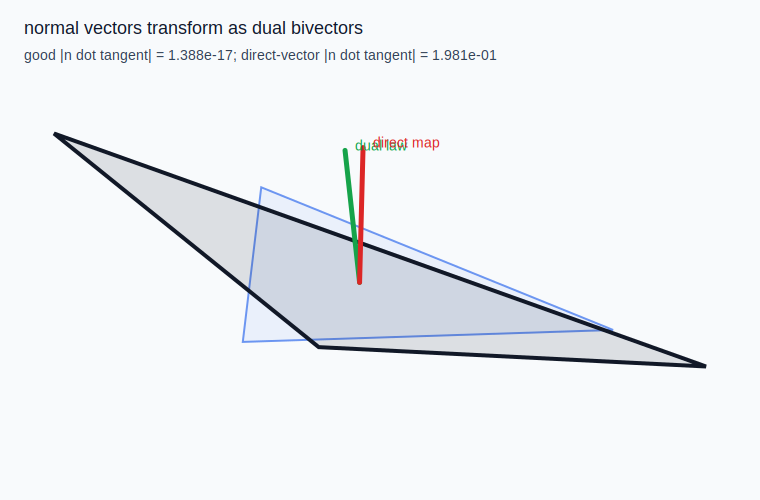

In [10]:
normal_svg = svg_normal_transform_lab(sx=1.70, sy=0.70, shear=0.45)
show_svg(normal_svg, "normal-transform-lab.svg")

In [11]:
if widgets is None:
    print("ipywidgets is not available in this runtime.")
else:
    sx = widgets.FloatSlider(value=1.7, min=0.45, max=2.3, step=0.05, description="sx")
    sy = widgets.FloatSlider(value=0.7, min=0.35, max=1.8, step=0.05, description="sy")
    shear = widgets.FloatSlider(value=0.45, min=-1.1, max=1.1, step=0.05, description="shear")

    @widgets.interact(sx=sx, sy=sy, shear=shear)
    def explore_normal_transform(sx, sy, shear):
        display(SVG(svg_normal_transform_lab(sx=sx, sy=sy, shear=shear)))

interactive(children=(FloatSlider(value=1.7, description='sx', max=2.3, min=0.45, step=0.05), FloatSlider(valu…

In [12]:
source_normal = bivector_to_normal(B)
dual_after_outermorphism = bivector_to_normal(exterior_power_matrix(M3, 2) @ B)
normal_formula = normal_transform(M3, source_normal)

print("dual of transformed bivector:", dual_after_outermorphism)
print("det(M) * M^{-T} * source normal:", normal_formula)
residual("dual transformation law", np.linalg.norm(dual_after_outermorphism - normal_formula))

dual of transformed bivector: [-0.7792  0.2629 -1.1465]
det(M) * M^{-T} * source normal: [-0.7792  0.2629 -1.1465]
dual transformation law: 0.000e+00


## 7. Matrix Representations of Outermorphisms

Once a basis-blade order is chosen, every outermorphism has ordinary matrices for each grade. For a 3-D vector map, the grade-0 matrix is `[1]`, grade 1 is the vector matrix, grade 2 is the matrix of all 2-by-2 minors, and grade 3 is `[det(M)]`.

The useful invariant for implementation is composition: applying one map and then another at the vector level must match multiplying the corresponding exterior-power matrices at every grade.

In [13]:
print("grade 0 matrix:")
print(exterior_power_matrix(M3, 0))
print("grade 1 matrix:")
print(exterior_power_matrix(M3, 1))
print("grade 2 matrix, basis e12/e13/e23:")
print(exterior_power_matrix(M3, 2))
print("grade 3 matrix:")
print(exterior_power_matrix(M3, 3))

N3 = np.array([[0.80, 0.10, -0.25], [-0.15, 1.10, 0.30], [0.20, -0.05, 0.95]])
compose_direct = exterior_power_matrix(M3 @ N3, 2)
compose_factored = exterior_power_matrix(M3, 2) @ exterior_power_matrix(N3, 2)
residual("grade-2 matrix composition", np.linalg.norm(compose_direct - compose_factored))

grade 0 matrix:
[[1.]]
grade 1 matrix:
[[ 1.15 -0.35  0.2 ]
 [ 0.25  0.92 -0.15]
 [ 0.05  0.38  1.08]]
grade 2 matrix, basis e12/e13/e23:
[[ 1.1455 -0.2225 -0.1315]
 [ 0.4545  1.232  -0.454 ]
 [ 0.049   0.2775  1.0506]]
grade 3 matrix:
[[1.3151]]
grade-2 matrix composition: 2.405e-16


## 8. Projection Lab

Projection is easiest to trust when the residual has the right geometry. In the first lab, a point is orthogonally dropped to a 2-D subspace. The vector from the projection back to the point must be perpendicular to both spanning vectors.

The second mini-lab matches the chapter's directional projection idea: project onto one line while moving parallel to another direction.

wrote Geometric-Algebra-for-Computer-Science/artifacts/chapter-04/projection-lab.svg


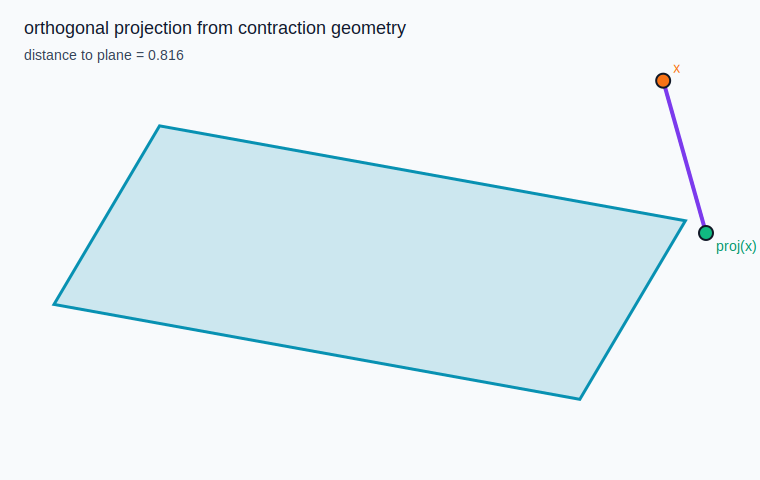

In [14]:
point = np.array([1.15, -0.75, 1.20])
projection_svg = svg_projection_lab(point)
show_svg(projection_svg, "projection-lab.svg")

In [15]:
plane_u = np.array([1.4, 0.15, 0.25])
plane_v = np.array([0.25, 1.15, -0.15])
projection = project_vector_to_subspace(point, np.vstack([plane_u, plane_v]))
rejection = point - projection

print("point:", point)
print("projection:", projection)
print("rejection:", rejection)
residual("rejection dot plane_u", np.dot(rejection, plane_u))
residual("rejection dot plane_v", np.dot(rejection, plane_v))

point: [ 1.15 -0.75  1.2 ]
projection: [ 1.3055 -0.8867  0.411 ]
rejection: [-0.1555  0.1367  0.789 ]
rejection dot plane_u: 2.220e-16
rejection dot plane_v: -2.220e-16


In [16]:
if widgets is None:
    print("ipywidgets is not available in this runtime.")
else:
    px = widgets.FloatSlider(value=1.15, min=-1.8, max=1.8, step=0.05, description="x")
    py = widgets.FloatSlider(value=-0.75, min=-1.8, max=1.8, step=0.05, description="y")
    pz = widgets.FloatSlider(value=1.20, min=-1.8, max=1.8, step=0.05, description="z")

    @widgets.interact(px=px, py=py, pz=pz)
    def explore_projection(px, py, pz):
        display(SVG(svg_projection_lab(np.array([px, py, pz]))))

interactive(children=(FloatSlider(value=1.15, description='x', max=1.8, min=-1.8, step=0.05), FloatSlider(valu…

In [17]:
line = np.array([1.0, 0.25])
along = np.array([-0.20, 1.0])
z = np.array([0.65, 1.35])
line_projection = directional_line_projection(z, line, along)
slide = z - line_projection

on_line_area = wedge_vectors(line_projection, line)[0]
slide_parallel_area = wedge_vectors(slide, along)[0]
print("z:", z)
print("projection onto line:", line_projection)
print("sliding residual direction:", slide)
residual("projected point lies on target line", on_line_area)
residual("projection traveled along the chosen direction", slide_parallel_area)

z: [0.65 1.35]
projection onto line: [0.8762 0.219 ]
sliding residual direction: [-0.2262  1.131 ]
projected point lies on target line: 0.000e+00
projection traveled along the chosen direction: 3.139e-17


## 9. Invariant Checklist

This last cell collects the chapter-level invariants into one compact audit. If you change any helper or experiment above, run this list again. The checks cover vector linearity, outermorphism behavior, determinant volume scaling, adjoints, transformed scalar products, transformed contractions, dual normals, and exterior-power matrix composition.

### What to keep from this chapter

A linear map in geometric algebra is more than a matrix applied to coordinate columns.  It is a family of compatible maps, one for each grade, tied together by the outer product.  The grade-one action moves vectors; the grade-two action moves oriented areas; the top-grade action exposes the determinant; the adjoint action preserves scalar pairings; the dual action explains normals and constraints.  Once this viewpoint is in place, many later formulas become less mysterious because they are all instances of the same compatibility demand.

When debugging code that implements these ideas, the fastest checks are geometric.  Does transforming a parallelogram by its two edges produce the same area blade as the grade-two matrix?  Does a singular map kill the correct blade?  Does the determinant agree with top-grade scaling?  Does an adjoint pairing give the same scalar from both sides?  Does a transformed normal remain perpendicular to transformed tangents?  These checks are deliberately redundant.  Redundancy is useful here because it catches mistakes in signs, basis order, and metric conventions before those mistakes appear as visual artifacts in a larger geometry pipeline.


In [18]:
checks = run_invariant_checks()
rows = []
for item in checks:
    marker = "PASS" if item.passed else "FAIL"
    rows.append(f"<tr><td>{marker}</td><td>{item.name}</td><td>{item.residual:.3e}</td></tr>")
html = "<table><thead><tr><th>status</th><th>check</th><th>residual</th></tr></thead><tbody>" + "".join(rows) + "</tbody></table>"
display(HTML(html))
path = write_json_artifact("invariant-checks.json", checks_as_dicts(checks))
print(f"wrote {path}")
assert all(item.passed for item in checks)
final_sanity = {"status": "checks executed"}
final_sanity


status,check,residual
PASS,outermorphism preserves wedge,2.220e-16
PASS,determinant scales trivectors,0.000e+00
PASS,adjoint transfers scalar product,5.551e-17
PASS,transformed scalar product uses pullback metric,5.551e-17
PASS,contraction transform needs inverse adjoint,2.529e-16
PASS,dual bivectors transform normals,1.241e-16
PASS,outermorphism matrices compose,7.286e-17


wrote Geometric-Algebra-for-Computer-Science/artifacts/chapter-04/invariant-checks.json


## Takeaways

- Linear maps act on vectors, and outermorphisms extend them to every blade by preserving the outer product.
- The determinant is the top-grade scale factor of the outermorphism.
- Metric products do not pass through arbitrary maps for free. Scalar products use the pulled-back metric, and contractions require an inverse adjoint on the contracted argument.
- Dual representations transform with the determinant and inverse adjoint. This is why surface normals should be transformed as duals of tangent bivectors, not as ordinary vectors.
- Matrix implementations are fine as long as each grade receives the correct exterior-power matrix.